Первые строки:


,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


Описание данных:


,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


Выбранные столбцы:


,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,CO2EMISSIONS
0,2.0,4,8.5,9.9,6.7,196
1,2.4,4,9.6,11.2,7.7,221
2,1.5,4,5.9,6.0,5.8,136
3,3.5,6,11.1,12.7,9.1,255
4,3.5,6,10.6,12.1,8.7,244
5,3.5,6,10.0,11.9,7.7,230
6,3.5,6,10.1,11.8,8.1,232
7,3.7,6,11.1,12.8,9.0,255
8,3.7,6,11.6,13.4,9.5,267


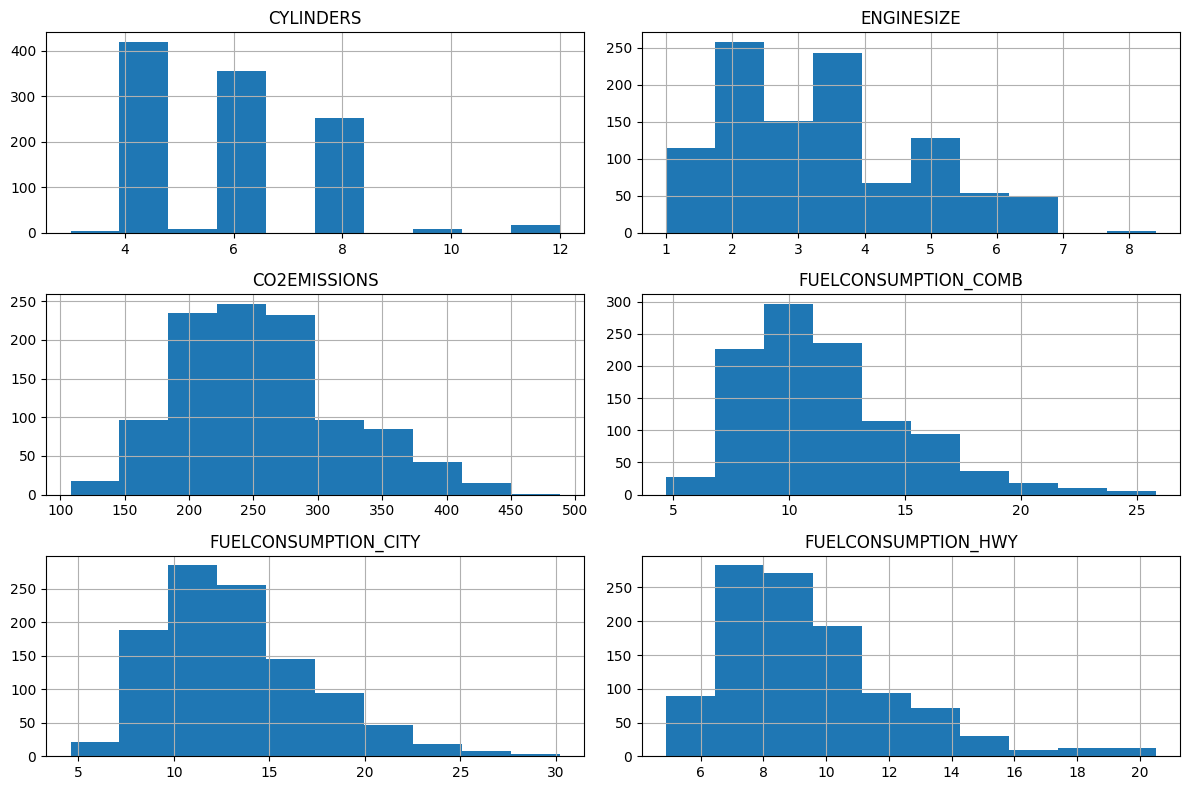

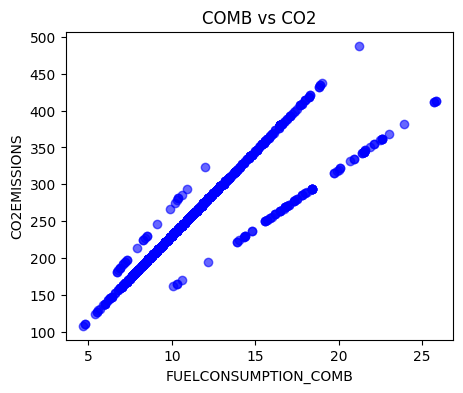

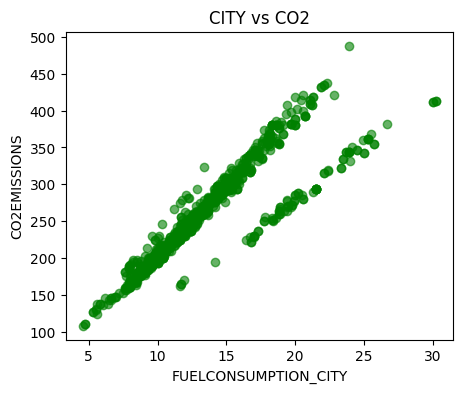

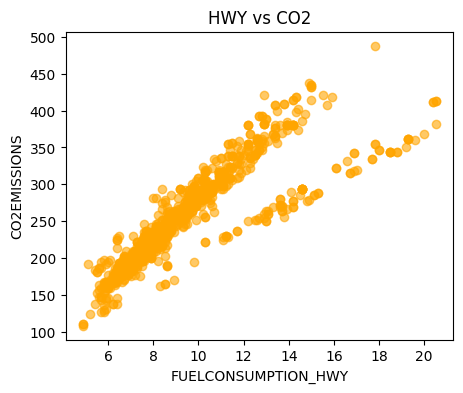

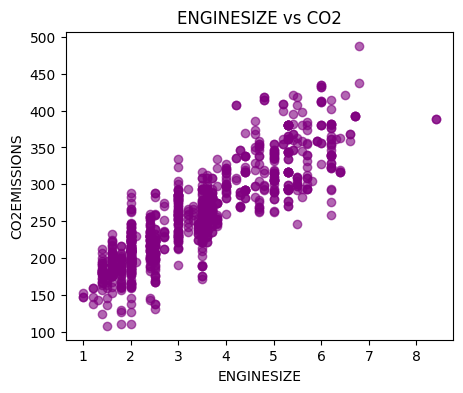

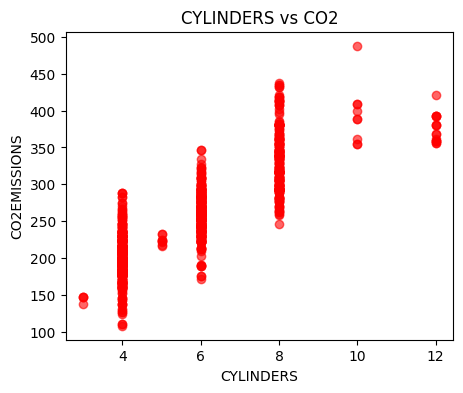

=== Модель с COMB ===
Coefficients: [[10.89017123  7.62774598  9.66386266]]
Intercept: [63.91569864]
Residual sum of squares (MSE): 488.66
Variance score (R2): 0.8726

=== Модель с CITY + HWY ===
Coefficients: [[10.96019553  7.25506017  6.21824671  3.16837622]]
Intercept: [65.05048368]
Residual sum of squares (MSE): 491.13
Variance score (R2): 0.8720

=== Сравнение моделей ===
COMB      -> MSE: 488.66, R2: 0.8726
CITY+HWY  -> MSE: 491.13, R2: 0.8720
Вывод: точность снизилась при использовании CITY + HWY.


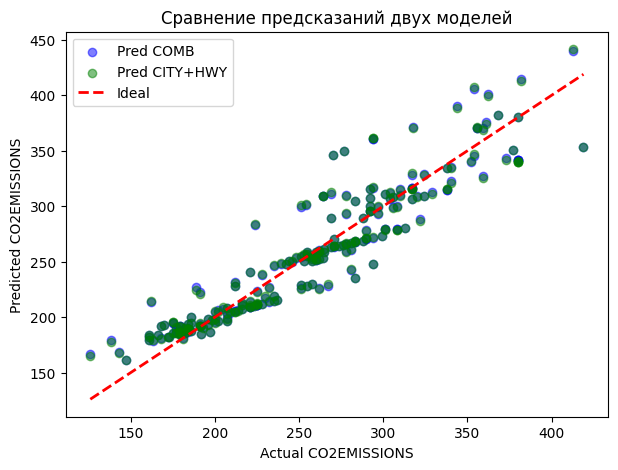

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
%matplotlib inline

df = pd.read_csv("/home/jupyter/work/data/FuelConsumption.csv")
print("Первые строки:")
display(df.head())

print("Описание данных:")
display(df.describe())

cdf = df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB',
          'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'CO2EMISSIONS']]
print("Выбранные столбцы:")
display(cdf.head(9))

# Гистограммы как в исходной работе
viz = cdf[['CYLINDERS', 'ENGINESIZE', 'CO2EMISSIONS',
           'FUELCONSUMPTION_COMB', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY']]
viz.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4))
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS, color='blue', alpha=0.6)
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("CO2EMISSIONS")
plt.title("COMB vs CO2")
plt.show()

plt.figure(figsize=(5,4))
plt.scatter(cdf.FUELCONSUMPTION_CITY, cdf.CO2EMISSIONS, color='green', alpha=0.6)
plt.xlabel("FUELCONSUMPTION_CITY")
plt.ylabel("CO2EMISSIONS")
plt.title("CITY vs CO2")
plt.show()

plt.figure(figsize=(5,4))
plt.scatter(cdf.FUELCONSUMPTION_HWY, cdf.CO2EMISSIONS, color='orange', alpha=0.6)
plt.xlabel("FUELCONSUMPTION_HWY")
plt.ylabel("CO2EMISSIONS")
plt.title("HWY vs CO2")
plt.show()

plt.figure(figsize=(5,4))
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color='purple', alpha=0.6)
plt.xlabel("ENGINESIZE")
plt.ylabel("CO2EMISSIONS")
plt.title("ENGINESIZE vs CO2")
plt.show()

plt.figure(figsize=(5,4))
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS, color='red', alpha=0.6)
plt.xlabel("CYLINDERS")
plt.ylabel("CO2EMISSIONS")
plt.title("CYLINDERS vs CO2")
plt.show()

np.random.seed(42)
msk = np.random.rand(len(df)) < 0.8

train = cdf[msk]
test = cdf[~msk]

from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

regr_comb = linear_model.LinearRegression()
x_train_comb = np.asanyarray(train[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']])
y_train = np.asanyarray(train[['CO2EMISSIONS']])

regr_comb.fit(x_train_comb, y_train)
print("=== Модель с COMB ===")
print("Coefficients:", regr_comb.coef_)
print("Intercept:", regr_comb.intercept_)

x_test_comb = np.asanyarray(test[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']])
y_test = np.asanyarray(test[['CO2EMISSIONS']])
y_hat_comb = regr_comb.predict(x_test_comb)

mse_comb = mean_squared_error(y_test, y_hat_comb)
r2_comb = r2_score(y_test, y_hat_comb)

print("Residual sum of squares (MSE): %.2f" % mse_comb)
print("Variance score (R2): %.4f" % r2_comb)

regr_city_hwy = linear_model.LinearRegression()
x_train_city_hwy = np.asanyarray(train[['ENGINESIZE', 'CYLINDERS',
                                        'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY']])

regr_city_hwy.fit(x_train_city_hwy, y_train)
print("\n=== Модель с CITY + HWY ===")
print("Coefficients:", regr_city_hwy.coef_)
print("Intercept:", regr_city_hwy.intercept_)

x_test_city_hwy = np.asanyarray(test[['ENGINESIZE', 'CYLINDERS',
                                      'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY']])
y_hat_city_hwy = regr_city_hwy.predict(x_test_city_hwy)

mse_city_hwy = mean_squared_error(y_test, y_hat_city_hwy)
r2_city_hwy = r2_score(y_test, y_hat_city_hwy)

print("Residual sum of squares (MSE): %.2f" % mse_city_hwy)
print("Variance score (R2): %.4f" % r2_city_hwy)

print("\n=== Сравнение моделей ===")
print(f"COMB      -> MSE: {mse_comb:.2f}, R2: {r2_comb:.4f}")
print(f"CITY+HWY  -> MSE: {mse_city_hwy:.2f}, R2: {r2_city_hwy:.4f}")

if (r2_city_hwy > r2_comb) and (mse_city_hwy < mse_comb):
    print("Вывод: точность повысилась при использовании CITY + HWY.")
elif (r2_city_hwy < r2_comb) and (mse_city_hwy > mse_comb):
    print("Вывод: точность снизилась при использовании CITY + HWY.")
else:
    print("Вывод: результаты близкие, однозначного улучшения нет.")

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_hat_comb, color='blue', alpha=0.5, label='Pred COMB')
plt.scatter(y_test, y_hat_city_hwy, color='green', alpha=0.5, label='Pred CITY+HWY')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal')
plt.xlabel("Actual CO2EMISSIONS")
plt.ylabel("Predicted CO2EMISSIONS")
plt.title("Сравнение предсказаний двух моделей")
plt.legend()
plt.show()